# Comparative Baseline V4 Official Collection

This notebook is a descriptive view of the immutable 18-observation official collection. It separates technical execution, semantic eligibility, grounding, correctness, and resource consumption. It does not rank conditions or make a product conclusion.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

candidates = [
    Path('../../ai-engine/data/comparative-baseline-v4/official-collection/v4-official-20260917T204411Z-e947a9a6'),
    Path('ai-engine/data/comparative-baseline-v4/official-collection/v4-official-20260917T204411Z-e947a9a6'),
]
DATA_ROOT = next(path for path in candidates if (path / 'official-dataset.csv').exists())
df = pd.read_csv(DATA_ROOT / 'official-dataset.csv')
numeric_columns = ['repetition', 'modelTurns', 'providerCalls', 'toolAttempts', 'executedToolOperations', 'invalidToolRequests', 'skippedToolOperations', 'ceilingCountedOperations', 'searches', 'reads', 'repositoryBytesDelivered', 'largestSingleResultBytesDelivered', 'inputTokens', 'outputTokens', 'providerLatency', 'totalLatency']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
df.head()

,question,condition,repetition,observationId,executionStatus,stopReason,structuralValid,groundingValid,semanticEvaluated,semanticCorrect,...,searches,reads,repositoryBytesDelivered,largestSingleResultBytesDelivered,inputTokens,outputTokens,providerLatency,totalLatency,cost,replayStatus
0,CASE-01-COMPARATIVE,AGENT_DIRECT_OPEN,1,v4-official-20260917T204411Z-e947a9a6:CASE-01-...,PROVIDER_FAILURE,PROVIDER_FAILURE,NOT_EVALUATED,NOT_EVALUATED,False,NOT_EVALUATED,...,3,3,64782,39296,3065.0,222.0,3250.0,8649,NOT_AVAILABLE,PASS
1,CASE-01-COMPARATIVE,AGENT_DIRECT_OPEN,2,v4-official-20260917T204411Z-e947a9a6:CASE-01-...,PROVIDER_FAILURE,PROVIDER_FAILURE,NOT_EVALUATED,NOT_EVALUATED,False,NOT_EVALUATED,...,2,2,57613,39296,1951.0,155.0,2530.0,8204,NOT_AVAILABLE,PASS
2,CASE-01-COMPARATIVE,AGENT_DIRECT_OPEN,3,v4-official-20260917T204411Z-e947a9a6:CASE-01-...,PROVIDER_FAILURE,PROVIDER_FAILURE,NOT_EVALUATED,NOT_EVALUATED,False,NOT_EVALUATED,...,4,2,57780,39296,2027.0,202.0,3271.0,7809,NOT_AVAILABLE,PASS
3,CASE-01-COMPARATIVE,DEVLOG,1,v4-official-20260917T204411Z-e947a9a6:CASE-01-...,COMPLETED,NOT_STOPPED,YES,FAIL,True,True,...,0,0,0,0,8460.0,841.0,7946.0,7949,NOT_AVAILABLE,PASS
4,CASE-01-COMPARATIVE,DEVLOG,2,v4-official-20260917T204411Z-e947a9a6:CASE-01-...,COMPLETED,NOT_STOPPED,YES,FAIL,True,True,...,0,0,0,0,8460.0,831.0,7170.0,7174,NOT_AVAILABLE,PASS


## 1. Experimental Context and Integrity

The frozen design contains three questions, two conditions, and three repetitions. Technical completeness is checked independently from answer quality.

In [2]:
assert len(df) == 18
assert df['question'].nunique() == 3
assert set(df['condition']) == {'DEVLOG', 'AGENT_DIRECT_OPEN'}
assert df['repetition'].nunique() == 3
assert set(df.groupby('condition').size()) == {9}
assert set(df.groupby('repetition').size()) == {6}
integrity = {
    'rows': len(df),
    'executionStatus': df['executionStatus'].value_counts().to_dict(),
    'replayStatus': df['replayStatus'].value_counts().to_dict(),
}
integrity

{'rows': 18,
 'executionStatus': {'COMPLETED': 7, 'PROVIDER_FAILURE': 6, 'CENSORED': 5},
 'replayStatus': {'PASS': 18}}

## 2. Execution Outcomes

Failure and censor outcomes are retained as experimental observations. They are not silently converted into incorrect answers.

In [3]:
status_by_condition = pd.crosstab(df['condition'], df['executionStatus'])
status_by_condition

executionStatus,CENSORED,COMPLETED,PROVIDER_FAILURE
condition,,,
AGENT_DIRECT_OPEN,5,0,4
DEVLOG,0,7,2


## 3. Semantic Eligibility and Quality

Semantic accuracy is calculated only among structurally eligible observations. A condition with few eligible answers must not be interpreted as having high overall answer quality merely because its conditional accuracy is high.

In [4]:
def normalize_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, str) and value.strip().lower() in {'true', 'yes'}:
        return True
    if isinstance(value, str) and value.strip().lower() in {'false', 'no'}:
        return False
    return pd.NA
df['semanticCorrectNormalized'] = df['semanticCorrect'].map(normalize_bool)
df['semanticEligible'] = df['semanticEvaluated'].map(normalize_bool).fillna(False) & df['structuralValid'].eq('YES')
def rate(series):
    return series.mean() if len(series) else float('nan')
quality = df.groupby('condition').apply(lambda g: pd.Series({
    'structural_valid_rate': rate(g['structuralValid'].eq('YES')),
    'grounding_valid_rate': rate(g['groundingValid'].eq('PASS')),
    'semantic_eligibility_rate': rate(g['semanticEligible']),
    'semantic_accuracy_when_eligible': rate(g.loc[g['semanticEligible'], 'semanticCorrectNormalized'].dropna()),
    'correct_grounded_rate': rate(g['correctGroundedAnswer'].eq(True)),
    'censor_rate': rate(g['executionStatus'].isin(['CENSORED', 'CENSORED_RUNAWAY'])),
    'provider_failure_rate': rate(g['executionStatus'].eq('PROVIDER_FAILURE')),
}))
quality

,structural_valid_rate,grounding_valid_rate,semantic_eligibility_rate,semantic_accuracy_when_eligible,correct_grounded_rate,censor_rate,provider_failure_rate
condition,,,,,,,
AGENT_DIRECT_OPEN,0.000000,0.0,0.000000,NaN,0.0,0.555556,0.444444
DEVLOG,0.555556,0.0,0.555556,0.8,0.0,0.000000,0.222222


## 4. Grounding Relationship

Structural validity, grounding validity, and semantic correctness are displayed as separate dimensions. A semantically correct but poorly grounded answer would remain visible rather than being collapsed into one failure category.

In [5]:
df.groupby(['structuralValid', 'groundingValid', 'semanticCorrect'], dropna=False).size().rename('observations').reset_index()

,structuralValid,groundingValid,semanticCorrect,observations
0,NO,NOT_EVALUATED,NOT_EVALUATED,2
1,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,11
2,YES,FAIL,False,1
3,YES,FAIL,True,4


## 5. Resource Consumption

Resource efficiency is descriptive only. Lower token or tool usage is not automatically better if no usable answer was produced. Cost is authoritative only when present; this dataset records `NOT_AVAILABLE`.

In [6]:
resource_summary = df.groupby('condition')[['providerCalls', 'modelTurns', 'toolAttempts', 'executedToolOperations', 'invalidToolRequests', 'skippedToolOperations', 'repositoryBytesDelivered', 'inputTokens', 'outputTokens', 'totalLatency']].sum()
resource_summary

,providerCalls,modelTurns,toolAttempts,executedToolOperations,invalidToolRequests,skippedToolOperations,repositoryBytesDelivered,inputTokens,outputTokens,totalLatency
condition,,,,,,,,,,
AGENT_DIRECT_OPEN,50,50,92,58,25,9,424786,246567.0,3162.0,110732
DEVLOG,7,7,0,0,0,0,0,45839.0,5499.0,78767


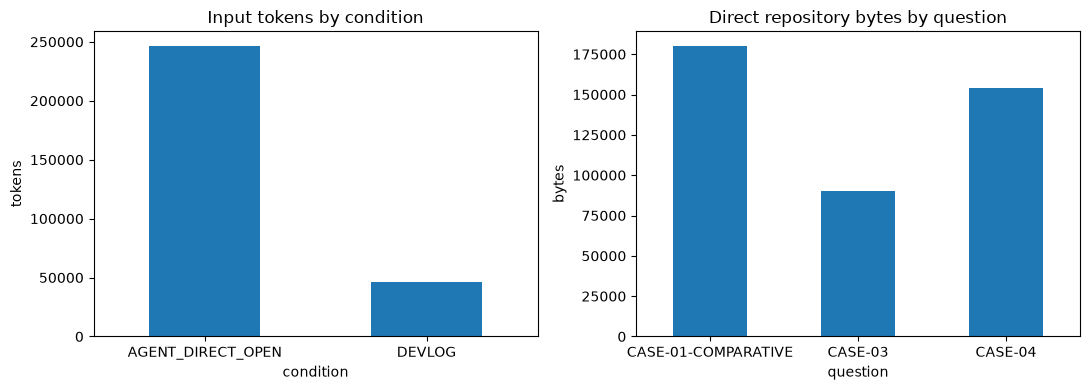

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.groupby('condition')['inputTokens'].sum().plot.bar(ax=axes[0], title='Input tokens by condition', ylabel='tokens', rot=0)
direct = df[df['condition'].eq('AGENT_DIRECT_OPEN')]
direct.groupby('question')['repositoryBytesDelivered'].sum().plot.bar(ax=axes[1], title='Direct repository bytes by question', ylabel='bytes', rot=0)
plt.tight_layout()

## 6. Direct-Agent Behavior

The direct condition is characterized through observed attempts, valid execution, invalid requests, skipped requests, search/read activity, and ceiling utilization. No preferred navigation trajectory is assumed.

In [8]:
direct[['question', 'repetition', 'executionStatus', 'toolAttempts', 'executedToolOperations', 'invalidToolRequests', 'skippedToolOperations', 'ceilingCountedOperations', 'searches', 'reads', 'repositoryBytesDelivered', 'stopReason']]

,question,repetition,executionStatus,toolAttempts,executedToolOperations,invalidToolRequests,skippedToolOperations,ceilingCountedOperations,searches,reads,repositoryBytesDelivered,stopReason
0,CASE-01-COMPARATIVE,1,PROVIDER_FAILURE,6,6,0,0,6,3,3,64782,PROVIDER_FAILURE
1,CASE-01-COMPARATIVE,2,PROVIDER_FAILURE,4,4,0,0,4,2,2,57613,PROVIDER_FAILURE
2,CASE-01-COMPARATIVE,3,PROVIDER_FAILURE,6,6,0,0,6,4,2,57780,PROVIDER_FAILURE
6,CASE-03,1,CENSORED,14,6,6,2,12,5,1,16368,SAFETY_MAX_TOOL_OPERATIONS
7,CASE-03,2,CENSORED,14,6,6,2,12,4,2,10400,SAFETY_MAX_TOOL_OPERATIONS
8,CASE-03,3,CENSORED,14,9,3,2,12,8,1,63686,SAFETY_MAX_TOOL_OPERATIONS
12,CASE-04,1,PROVIDER_FAILURE,7,7,0,0,7,4,3,58564,PROVIDER_FAILURE
13,CASE-04,2,CENSORED,13,7,5,1,12,4,3,60453,SAFETY_MAX_TOOL_OPERATIONS
14,CASE-04,3,CENSORED,14,7,5,2,12,5,2,35140,SAFETY_MAX_TOOL_OPERATIONS


## 7. Paired Repetitions and Stability

Each question-condition pair is shown across all three repetitions. The small sample is treated as descriptive evidence; no significance testing or superiority claim is made.

In [9]:
stability = df.sort_values(['question', 'condition', 'repetition']).set_index(['question', 'condition', 'repetition'])[['executionStatus', 'semanticEligible', 'semanticCorrect', 'groundingValid', 'providerCalls', 'toolAttempts']]
stability

executionStatus  \
question            condition         repetition                     
CASE-01-COMPARATIVE AGENT_DIRECT_OPEN 1           PROVIDER_FAILURE   
                                      2           PROVIDER_FAILURE   
                                      3           PROVIDER_FAILURE   
                    DEVLOG            1                  COMPLETED   
                                      2                  COMPLETED   
                                      3           PROVIDER_FAILURE   
CASE-03             AGENT_DIRECT_OPEN 1                   CENSORED   
                                      2                   CENSORED   
                                      3                   CENSORED   
                    DEVLOG            1                  COMPLETED   
                                      2           PROVIDER_FAILURE   
                                      3                  COMPLETED   
CASE-04             AGENT_DIRECT_OPEN 1           PROVIDER_FAILURE   
                                      2                   CENSORED   
                                      3                   CENSORED   
                    DEVLOG            1                  COMPLETED   
                                      2                  COMPLETED   
                                      3                  COMPLETED   

                                                  semanticEligible  \
question            condition         repetition                     
CASE-01-COMPARATIVE AGENT_DIRECT_OPEN 1                      False   
                                      2                      False   
                                      3                      False   
                    DEVLOG            1                       True   
                                      2                       True   
                                      3                      False   
CASE-03             AGENT_DIRECT_OPEN 1                      False   
                                      2                      False   
                                      3                      False   
                    DEVLOG            1                      False   
                                      2                      False   
                                      3                      False   
CASE-04             AGENT_DIRECT_OPEN 1                      False   
                                      2                      False   
                                      3                      False   
                    DEVLOG            1                       True   
                                      2                       True   
                                      3                       True   

                                                 semanticCorrect  \
question            condition         repetition                   
CASE-01-COMPARATIVE AGENT_DIRECT_OPEN 1            NOT_EVALUATED   
                                      2            NOT_EVALUATED   
                                      3            NOT_EVALUATED   
                    DEVLOG            1                     True   
                                      2                     True   
                                      3            NOT_EVALUATED   
CASE-03             AGENT_DIRECT_OPEN 1            NOT_EVALUATED   
                                      2            NOT_EVALUATED   
                                      3            NOT_EVALUATED   
                    DEVLOG            1            NOT_EVALUATED   
                                      2            NOT_EVALUATED   
                                      3            NOT_EVALUATED   
CASE-04             AGENT_DIRECT_OPEN 1            NOT_EVALUATED   
                                      2            NOT_EVALUATED   
                                      3            NOT_EVALUATED   
                    DEVLOG            1                     True   
                         

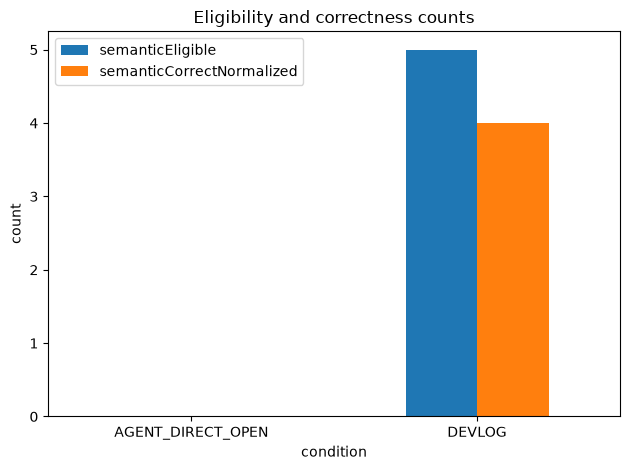

In [10]:
df.groupby('condition')[['semanticEligible', 'semanticCorrectNormalized']].sum().plot.bar(title='Eligibility and correctness counts', ylabel='count', rot=0)
plt.tight_layout()

## 8. Limitations and Human Interpretation

This is n=18 with three repetitions per question-condition pair. Provider/model failures, censoring, grounding failures, and `NOT_EVALUATED` outcomes limit direct quality comparisons. Monetary cost is unavailable. The next step is joint human review of this immutable dataset and the V3 diagnostic baseline before proposing a new DevLog hypothesis or architecture iteration.